In [1]:
!pip install xgboost lightgbm catboost
!pip install optuna



In [2]:
!pip install shap

In [10]:
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from lightgbm import early_stopping
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Ẩn bớt log chi tiết của Optuna để màn hình sạch sẽ

# =====================================================================
# 1. CẤU HÌNH HỆ THỐNG VÀ DANH SÁCH TẬP DỮ LIỆU
# =====================================================================
datasets = [
    {"ticker": "JPM", "filename": "JPM_master_trees_updated.csv"},
    {"ticker": "WFC", "filename": "WFC_master_trees_updated.csv"},
    {"ticker": "BAC", "filename": "BAC_master_trees_updated.csv"},
]

exclude_cols = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume", "target_return", "target_direction"]
target_reg = "target_return"
test_years = [2023, 2024, 2025]
EARLY_STOPPING_ROUNDS = 30

# Nơi lưu trữ bộ tham số tối ưu sau khi tune xong
BEST_PARAMS_MASTER = {
    "XGBoost": {},
    "LightGBM": {},
    "CatBoost": {}
}

# =====================================================================
# 2. ĐỊNH NGHĨA CÁC HÀM MỤC TIÊU (OBJECTIVE FUNCTIONS) CHO OPTUNA
# =====================================================================

def objective_xgb(trial, df, features, years):
    # Định nghĩa Search Space an toàn cho XGBoost chống học nhiễu
    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 5),               # Cây nông tránh fit nhiễu phẳng
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05), # Học chậm, chắc chắn
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),         # Lấy mẫu dòng ngẫu nhiên
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.7), # Giới hạn số lượng feature/cây
        "min_child_weight": trial.suggest_int("min_child_weight", 15, 50), # Ép số mẫu tối thiểu trong lá cao lên
        "gamma": trial.suggest_float("gamma", 0.1, 1.0),                 # Phạt phân nhánh
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 0.5),        # L1 để triệt tiêu bớt feature nhiễu
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),       # L2 chuẩn hóa
        "random_state": 42,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
    }

    val_scores = []
    for test_yr in test_years:
        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)

        X_train, y_train = df.loc[train_mask, features].values, df.loc[train_mask, target_reg].values
        X_val, y_val = df.loc[val_mask, features].values, df.loc[val_mask, target_reg].values

        model = xgb.XGBRegressor(**params, early_stopping_rounds=EARLY_STOPPING_ROUNDS)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        val_scores.append(mean_squared_error(y_val, preds))

    return np.mean(val_scores)


def objective_lgb(trial, df, features, years):
    # Định nghĩa Search Space an toàn cho LightGBM
    params = {
        "n_estimators": 1000,
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "num_leaves": trial.suggest_int("num_leaves", 7, 23),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.7),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 50), # Tương đương min_data_in_leaf
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),
        "random_state": 42,
        "objective": "regression",
        "metric": "rmse",
        "verbose": -1
    }

    val_scores = []
    for test_yr in test_years:
        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)

        X_train, y_train = df.loc[train_mask, features].values, df.loc[train_mask, target_reg].values
        X_val, y_val = df.loc[val_mask, features].values, df.loc[val_mask, target_reg].values

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)])

        preds = model.predict(X_val)
        val_scores.append(mean_squared_error(y_val, preds))

    return np.mean(val_scores)


def objective_cat(trial, df, features, years):
    # Định nghĩa Search Space an toàn cho CatBoost
    params = {
        "iterations": 1000,
        "depth": trial.suggest_int("depth", 3, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3.0, 10.0),    # Ép trọng số phạt L2 cao để chống nhiễu
        "random_seed": 42,
        "loss_function": "RMSE",
        "verbose": 0,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS
    }

    val_scores = []
    for test_yr in test_years:
        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)

        X_train, y_train = df.loc[train_mask, features].values, df.loc[train_mask, target_reg].values
        X_val, y_val = df.loc[val_mask, features].values, df.loc[val_mask, target_reg].values

        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

        preds = model.predict(X_val)
        val_scores.append(mean_squared_error(y_val, preds))

    return np.mean(val_scores)

# =====================================================================
# 3. VÒNG LẶP TUNING TỰ ĐỘNG CHO CẢ 3 NGÂN HÀNG
# =====================================================================

for dataset in datasets:
    ticker = dataset["ticker"]
    filename = dataset["filename"]

    print("\n" + "="*90)
    print(f" ⏳ ĐANG TIẾN HÀNH TUNING SIÊU THAM SỐ CHO NGÂN HÀNG: {ticker}")
    print("="*90)

    try:
        df_models = pd.read_csv(filename)
        df_models["Date"] = pd.to_datetime(df_models["Date"])
        df_models = df_models.sort_values("Date").reset_index(drop=True)
    except FileNotFoundError:
        print(f"❌ Không tìm thấy file {filename}. Bỏ qua...")
        continue

    features = [c for c in df_models.columns if c not in exclude_cols]
    years = df_models["Date"].dt.year

    # --- TUNE XGBOOST ---
    print(" 🛠️ Tuning XGBoost...")
    study_xgb = optuna.create_study(direction="minimize")
    study_xgb.optimize(lambda trial: objective_xgb(trial, df_models, features, years), n_trials=30)
    BEST_PARAMS_MASTER["XGBoost"][ticker] = study_xgb.best_params
    print(f"   ↳ Best MSE: {study_xgb.best_value:.6f} | Params: {study_xgb.best_params}")

    # --- TUNE LIGHTGBM ---
    print(" 🛠️ Tuning LightGBM...")
    study_lgb = optuna.create_study(direction="minimize")
    study_lgb.optimize(lambda trial: objective_lgb(trial, df_models, features, years), n_trials=30)
    BEST_PARAMS_MASTER["LightGBM"][ticker] = study_lgb.best_params
    print(f"   ↳ Best MSE: {study_lgb.best_value:.6f} | Params: {study_lgb.best_params}")

    # --- TUNE CATBOOST ---
    print(" 🛠️ Tuning CatBoost...")
    study_cat = optuna.create_study(direction="minimize")
    study_cat.optimize(lambda trial: objective_cat(trial, df_models, features, years), n_trials=30)
    BEST_PARAMS_MASTER["CatBoost"][ticker] = study_cat.best_params
    print(f"   ↳ Best MSE: {study_cat.best_value:.6f} | Params: {study_cat.best_params}")

print("\n" + "="*90)
print(" ✅ QUY TRÌNH TUNING HOÀN TẤT! DƯỚI ĐÂY LÀ BỘ THAM SỐ TỐI ƯU CỦA BẠN:")
print("="*90)
import pprint
pprint.pprint(BEST_PARAMS_MASTER)


 ⏳ ĐANG TIẾN HÀNH TUNING SIÊU THAM SỐ CHO NGÂN HÀNG: JPM
 🛠️ Tuning XGBoost...
   ↳ Best MSE: 0.000246 | Params: {'max_depth': 3, 'learning_rate': 0.037415378525325685, 'subsample': 0.6327649073262215, 'colsample_bytree': 0.5456758308736126, 'min_child_weight': 15, 'gamma': 0.7404221459765205, 'reg_alpha': 0.12560924695376774, 'reg_lambda': 1.634239336782673}
 🛠️ Tuning LightGBM...
   ↳ Best MSE: 0.000243 | Params: {'max_depth': 4, 'num_leaves': 19, 'learning_rate': 0.023116240178703146, 'subsample': 0.7239409995886645, 'colsample_bytree': 0.6680771133490194, 'min_child_samples': 40, 'reg_alpha': 0.03888162970154822, 'reg_lambda': 4.753913456063166}
 🛠️ Tuning CatBoost...
   ↳ Best MSE: 0.000245 | Params: {'depth': 3, 'learning_rate': 0.0396393317270064, 'l2_leaf_reg': 9.738122954255534}

 ⏳ ĐANG TIẾN HÀNH TUNING SIÊU THAM SỐ CHO NGÂN HÀNG: WFC
 🛠️ Tuning XGBoost...
   ↳ Best MSE: 0.000357 | Params: {'max_depth': 3, 'learning_rate': 0.0440877227329642, 'subsample': 0.7143180902096985,

In [6]:
import warnings
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import early_stopping
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
)
import xgboost as xgb

warnings.filterwarnings("ignore")

# =====================================================================
# CẤU HÌNH HỆ THỐNG VÀ BẢN ĐỒ THAM SỐ TỪ OPTUNA (TỪNG MÃ / TỪNG MODEL)
# =====================================================================

# Danh sách các tập dữ liệu cần chạy
datasets = [
    {"ticker": "JPM", "filename": "JPM_master_trees_updated.csv"},
    {"ticker": "WFC", "filename": "WFC_master_trees_updated.csv"},
    {"ticker": "BAC", "filename": "BAC_master_trees_updated.csv"},
]

# Tích hợp kết quả tối ưu thu được từ quá trình Tuning Optuna
TUNED_MASTER = {
    "XGBoost": {
        "JPM": {'max_depth': 4, 'learning_rate': 0.049058808061058196, 'subsample': 0.727340010934087, 'colsample_bytree': 0.666468886903079, 'min_child_weight': 49, 'gamma': 0.5711893326265831, 'reg_alpha': 0.013828809392105672, 'reg_lambda': 3.4481325677520527},
        "WFC": {'max_depth': 4, 'learning_rate': 0.026877835805663206, 'subsample': 0.6653747175917961, 'colsample_bytree': 0.5931191313343727, 'min_child_weight': 21, 'gamma': 0.24038312652487864, 'reg_alpha': 0.011185787994639453, 'reg_lambda': 1.2101750941169094},
        "BAC": {'max_depth': 3, 'learning_rate': 0.046451643847658756, 'subsample': 0.6358527462288843, 'colsample_bytree': 0.5014793178751723, 'min_child_weight': 31, 'gamma': 0.4092225406157449, 'reg_alpha': 0.15521821216501946, 'reg_lambda': 2.1020439898595313}
    },
    "LightGBM": {
        "JPM": {'max_depth': 5, 'num_leaves': 13, 'learning_rate': 0.023694232293310708, 'subsample': 0.7825552524142598, 'colsample_bytree': 0.6178065013540016, 'min_child_samples': 21, 'reg_alpha': 0.05746115659047471, 'reg_lambda': 2.5287816638140246},
        "WFC": {'max_depth': 4, 'num_leaves': 16, 'learning_rate': 0.027375949491699005, 'subsample': 0.6514935848327946, 'colsample_bytree': 0.6031671139926469, 'min_child_samples': 43, 'reg_alpha': 0.06381033284814369, 'reg_lambda': 4.55153515336605},
        "BAC": {'max_depth': 5, 'num_leaves': 11, 'learning_rate': 0.04854019013730422, 'subsample': 0.6622239940539567, 'colsample_bytree': 0.6330284346415295, 'min_child_samples': 45, 'reg_alpha': 0.40787984918546716, 'reg_lambda': 1.475925844350391}
    },
    "CatBoost": {
        "JPM": {'depth': 3, 'learning_rate': 0.026106390523326344, 'l2_leaf_reg': 7.82791596455951},
        "WFC": {'depth': 5, 'learning_rate': 0.045293787409926234, 'l2_leaf_reg': 5.705116216074926},
        "BAC": {'depth': 4, 'learning_rate': 0.01876546174433382, 'l2_leaf_reg': 8.0045642248034}
    }
}

EARLY_STOPPING_ROUNDS = 40

# =====================================================================
# KHỞI TẠO CÁC THÙNG CHỨA DỮ LIỆU TOÀN CỤC CHỐNG LỖI GHI ĐÈ
# =====================================================================
fitted_models = {
    "XGBoost": {},
    "LightGBM": {},
    "CatBoost": {}
}
all_results_master = {}   # Lưu kết quả dự báo và thực tế riêng biệt cho từng Ticker
all_features_master = {}  # Lưu danh sách features riêng biệt cho từng Ticker
all_dfs_master = {}       # Lưu DataFrame đã tiền xử lý riêng biệt cho từng Ticker

# =====================================================================
# VÒNG LẶP CHÍNH DUYỆT QUA TỪNG NGÂN HÀNG
# =====================================================================

for dataset in datasets:
    ticker = dataset["ticker"]
    filename = dataset["filename"]

    print("\n" + "="*90)
    print(f" KHỞI CHẠY PIPELINE CHO NGÂN HÀNG: {ticker} (File: {filename})")
    print("="*90)

    try:
        # 1. Đọc và chuẩn hóa cấu trúc dữ liệu
        df_models = pd.read_csv(filename)
        df_models["Date"] = pd.to_datetime(df_models["Date"])
        df_models = df_models.sort_values("Date").reset_index(drop=True)
        all_dfs_master[ticker] = df_models  # Lưu trữ dữ liệu ngân hàng gốc
    except FileNotFoundError:
        print(f"❌ Không tìm thấy file {filename}. Bỏ qua ngân hàng {ticker}.")
        continue

    # 2. Phân tách danh sách Features và Target
    exclude_cols = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume", "target_return", "target_direction"]
    features = [c for c in df_models.columns if c not in exclude_cols]
    all_features_master[ticker] = features  # Lưu trữ danh sách features
    target_reg = "target_return"

    years = df_models["Date"].dt.year
    test_years = [2023, 2024, 2025]

    # Khởi tạo cấu trúc lưu trữ kết quả cục bộ cho ngân hàng hiện tại
    results_dict = {
        "XGBoost": {"preds": [], "actuals": []},
        "LightGBM": {"preds": [], "actuals": []},
        "CatBoost": {"preds": [], "actuals": []},
    }

    print(f"Số lượng Features ghi nhận: {len(features)}")

    # 4. VÒNG LẶP WALK-FORWARD VALIDATION TỪNG NĂM
    for test_yr in test_years:
        print(f"  ▶ Đang xử lý khối kiểm thử dữ liệu năm: {test_yr}")

        train_mask = (years >= 2020) & (years < (test_yr - 1))
        val_mask = years == (test_yr - 1)
        test_mask = years == test_yr

        X_train = df_models.loc[train_mask, features].values
        y_train = df_models.loc[train_mask, target_reg].values

        X_val = df_models.loc[val_mask, features].values
        y_val = df_models.loc[val_mask, target_reg].values

        X_test = df_models.loc[test_mask, features].values
        y_test = df_models.loc[test_mask, target_reg].values

        X_train_full = np.vstack([X_train, X_val])
        y_train_full = np.concatenate([y_train, y_val])

        # --- MODEL 1: XGBOOST (Tuned từ Optuna) ---
        xgb_fold_params = {
            "n_estimators": 1500,
            "random_state": 42,
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            **TUNED_MASTER["XGBoost"][ticker]
        }

        # Phase 1: Tìm số cây tối ưu
        model_xgb = xgb.XGBRegressor(**xgb_fold_params)
        model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        best_iter_xgb = model_xgb.best_iteration

        # Phase 2: Retrain trên tập dữ liệu gộp đầy đủ
        xgb_retrain_params = {
            **xgb_fold_params,
            "n_estimators": max(100, best_iter_xgb + 25),
            "early_stopping_rounds": None
        }
        model_xgb_retrain = xgb.XGBRegressor(**xgb_retrain_params)
        model_xgb_retrain.fit(X_train_full, y_train_full, verbose=False)
        preds_xgb = model_xgb_retrain.predict(X_test)

        results_dict["XGBoost"]["preds"].extend(preds_xgb)
        results_dict["XGBoost"]["actuals"].extend(y_test)

        # Lưu trữ mô hình XGBoost của năm cuối cùng (2025) để làm SHAP
        if test_yr == 2025:
            fitted_models["XGBoost"][ticker] = model_xgb_retrain

        # --- MODEL 2: LIGHTGBM (Tuned từ Optuna) ---
        lgb_fold_params = {
            "n_estimators": 1500,
            "random_state": 42,
            "objective": "regression",
            "metric": "rmse",
            "verbose": -1,
            **TUNED_MASTER["LightGBM"][ticker]
        }

        model_lgb = lgb.LGBMRegressor(**lgb_fold_params)
        model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)])
        best_iter_lgb = model_lgb.best_iteration_

        lgb_retrain_params = {
            **lgb_fold_params,
            "n_estimators": max(100, best_iter_lgb + 25)
        }
        model_lgb_retrain = lgb.LGBMRegressor(**lgb_retrain_params)
        model_lgb_retrain.fit(X_train_full, y_train_full)
        preds_lgb = model_lgb_retrain.predict(X_test)

        results_dict["LightGBM"]["preds"].extend(preds_lgb)
        results_dict["LightGBM"]["actuals"].extend(y_test)

        # Lưu trữ mô hình LightGBM của năm cuối cùng (2025) để làm SHAP
        if test_yr == 2025:
            fitted_models["LightGBM"][ticker] = model_lgb_retrain

        # --- MODEL 3: CATBOOST (Tuned từ Optuna) ---
        cat_fold_params = {
            "iterations": 1500,
            "random_seed": 42,
            "loss_function": "RMSE",
            "verbose": 0,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            **TUNED_MASTER["CatBoost"][ticker]
        }

        model_cat = CatBoostRegressor(**cat_fold_params)
        model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        best_iter_cat = model_cat.get_best_iteration()

        cat_retrain_params = {
            **cat_fold_params,
            "iterations": max(100, best_iter_cat + 25),
            "early_stopping_rounds": None
        }
        model_cat_retrain = CatBoostRegressor(**cat_retrain_params)
        model_cat_retrain.fit(X_train_full, y_train_full, verbose=False)
        preds_cat = model_cat_retrain.predict(X_test)

        results_dict["CatBoost"]["preds"].extend(preds_cat)
        results_dict["CatBoost"]["actuals"].extend(y_test)

        # Lưu trữ mô hình CatBoost của năm cuối cùng (2025) để làm SHAP
        if test_yr == 2025:
            fitted_models["CatBoost"][ticker] = model_cat_retrain

        # Ghi nhận log cây tối ưu
        rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
        rmse_lgb = np.sqrt(mean_squared_error(y_test, preds_lgb))
        rmse_cat = np.sqrt(mean_squared_error(y_test, preds_cat))
        print(f"    ↳ Best Trees -> XGB:{best_iter_xgb} | LGB:{best_iter_lgb} | CAT:{best_iter_cat}")
        print(f"    ↳ [Fold RMSE] XGB: {rmse_xgb:.5f} | LGB: {rmse_lgb:.5f} | CAT: {rmse_cat:.5f}")

    # Đóng gói và lưu kết quả dự báo toàn bộ 3 năm vào Master Dictionary
    all_results_master[ticker] = results_dict

    # 5. XUẤT BẢNG TỔNG HỢP HIỆU SUẤT CHO NGÂN HÀNG HIỆN TẠI
    final_report = []
    confusion_matrices = {}

    for m_name, data in results_dict.items():
        actuals = np.array(data["actuals"])
        preds = np.array(data["preds"])

        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mae = mean_absolute_error(actuals, preds)

        dir_actual = np.where(actuals > 0, 1, 0)

        # Áp dụng ngưỡng động dựa trên Mean phân phối dự báo thực tế để tính Performance Metrics
        threshold = np.mean(preds)
        dir_pred = np.where(preds > threshold, 1, 0)

        acc = np.mean(dir_actual == dir_pred) * 100
        prec = precision_score(dir_actual, dir_pred, zero_division=0)
        rec = recall_score(dir_actual, dir_pred, zero_division=0)
        f1 = f1_score(dir_actual, dir_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(dir_actual, dir_pred).ravel()
        confusion_matrices[m_name] = {"TN": tn, "FP": fp, "FN": fn, "TP": tp}

        final_report.append({
            "Model": m_name, "RMSE": round(rmse, 5), "MAE": round(mae, 5),
            "Directional Acc (%)": round(acc, 2), "Precision": round(prec, 4),
            "Recall": round(rec, 4), "F1-Score": round(f1, 4),
        })

    report_df = pd.DataFrame(final_report)

    print("\n" + "=" * 80)
    print(f"=== BẢNG SO SÁNH HIỆU SUẤT HỒI QUY TỔNG THỂ - NGÂN HÀNG {ticker} (2023-2025) ===")
    print("=" * 80)
    print(report_df.to_string(index=False))
    print("=" * 80)

    # 6. IN MA TRẬN NHẦM LẪN CHI TIẾT DẠNG VĂN BẢN
    print("\n=== CHI TIẾT MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - " + ticker + " ===")
    for m_name, cm in confusion_matrices.items():
        total = cm["TN"] + cm["FP"] + cm["FN"] + cm["TP"]
        print(f"\n▶ MÔ HÌNH: {m_name}")
        print(f"  +-------------------+-------------------+-------------------+")
        print(f"  |                   | Dự báo GIẢM (0)   | Dự báo TĂNG (1)   |")
        print(f"  +-------------------+-------------------+-------------------+")
        print(f"  | Thực tế GIẢM (0)  | TN: {cm['TN']:<5} ({cm['TN']/total*100:.1f}%) | FP: {cm['FP']:<5} ({cm['FP']/total*100:.1f}%) |")
        print(f"  | Thực tế TĂNG (1)  | FN: {cm['FN']:<5} ({cm['FN']/total*100:.1f}%) | TP: {cm['TP']:<5} ({cm['TP']/total*100:.1f}%) |")
        print(f"  +-------------------+-------------------+-------------------+")

# =====================================================================
# 7. THỐNG KÊ PHÂN PHỐI DỰ BÁO CUỐI CÙNG CHO CẢ 3 NGÂN HÀNG (Ngoài Loop)
# =====================================================================
print("\n" + "=" * 90)
print("=== BÁO CÁO PHÂN PHỐI DỰ BÁO CHI TIẾT TOÀN HỆ THỐNG (2023-2025) ===")
print("=" * 90)

for ticker in all_results_master.keys():
    print(f"\n🏢 NGÂN HÀNG: {ticker}")
    print("-" * 50)
    direction_report = []

    for model_name in ["XGBoost", "LightGBM", "CatBoost"]:
        preds = np.array(all_results_master[ticker][model_name]["preds"])
        direction_report.append({
            "Model": model_name,
            "Min": round(preds.min(), 6),
            "Max": round(preds.max(), 6),
            "Mean": round(preds.mean(), 6),
            "Std": round(preds.std(), 6),
            "% Positive": round((preds > 0).mean() * 100, 2),
            "% Negative": round((preds <= 0).mean() * 100, 2)
        })

    direction_df = pd.DataFrame(direction_report)
    print(direction_df.to_string(index=False))
    print("-" * 50)


 KHỞI CHẠY PIPELINE CHO NGÂN HÀNG: JPM (File: JPM_master_trees_updated.csv)
Số lượng Features ghi nhận: 45
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2023
    ↳ Best Trees -> XGB:13 | LGB:1 | CAT:7
    ↳ [Fold RMSE] XGB: 0.01305 | LGB: 0.01293 | CAT: 0.01307
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2024
    ↳ Best Trees -> XGB:96 | LGB:67 | CAT:32
    ↳ [Fold RMSE] XGB: 0.01467 | LGB: 0.01451 | CAT: 0.01477
  ▶ Đang xử lý khối kiểm thử dữ liệu năm: 2025
    ↳ Best Trees -> XGB:27 | LGB:125 | CAT:25
    ↳ [Fold RMSE] XGB: 0.01573 | LGB: 0.01623 | CAT: 0.01595

=== BẢNG SO SÁNH HIỆU SUẤT HỒI QUY TỔNG THỂ - NGÂN HÀNG JPM (2023-2025) ===
   Model    RMSE     MAE  Directional Acc (%)  Precision  Recall  F1-Score
 XGBoost 0.01452 0.00990                47.40     0.5663  0.3294    0.4165
LightGBM 0.01462 0.01010                50.47     0.5749  0.5023    0.5362
CatBoost 0.01464 0.00998                47.14     0.5622  0.3271    0.4136

=== CHI TIẾT MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - JPM =


===== TOP 10 SHAP FEATURES - JPM (LightGBM) =====
         Feature  SHAP Importance
   overnight_gap         0.000579
VIX_volatility_5         0.000562
            MACD         0.000490
   volatility_20         0.000483
 VIX_return_lag1         0.000472
  VIX_momentum_5         0.000441
      VIX_return         0.000408
       return_1d         0.000357
    lag_return_3         0.000289
       VIX_Close         0.000277


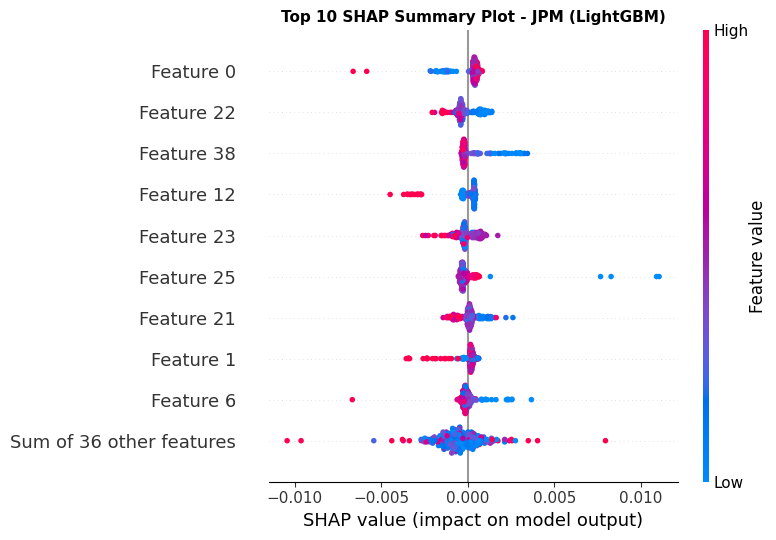


===== TOP 10 SHAP FEATURES - WFC (LightGBM) =====
          Feature  SHAP Importance
             MACD         0.000575
      MACD_Signal         0.000389
     lag_return_3         0.000370
       XLF_return         0.000359
 VIX_volatility_5         0.000353
     lag_return_1         0.000336
     lag_return_2         0.000331
SPX_volatility_20         0.000331
  VIX_return_lag1         0.000331
 XLF_volatility_5         0.000319


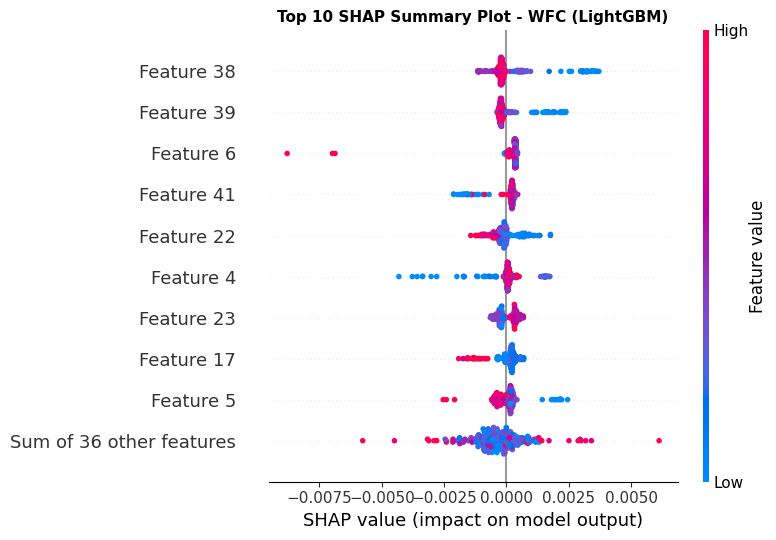


===== TOP 10 SHAP FEATURES - BAC (LightGBM) =====
         Feature  SHAP Importance
   overnight_gap         0.000761
VIX_volatility_5         0.000633
     MACD_Signal         0.000592
    lag_return_3         0.000539
    volume_shock         0.000515
      VIX_return         0.000505
       return_3d         0.000492
 Rolling_Beta_30         0.000457
    lag_return_5         0.000381
           DGS10         0.000375


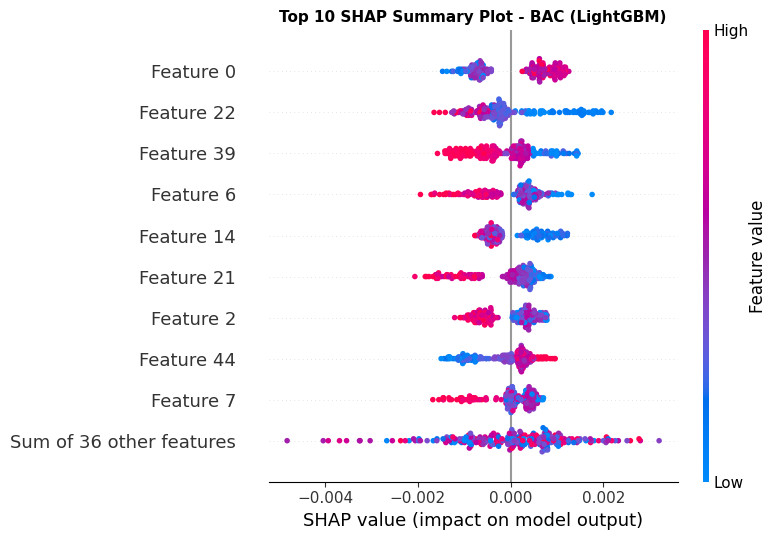

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "LightGBM"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]

    # Lọc snapshot năm 2025
    test_mask = df_single["Date"].dt.year == 2025
    df_oos = df_single.loc[test_mask].reset_index(drop=True)
    X_test_snapshot = df_oos[features_single].values

    current_model = fitted_models[TARGET_MODEL_NAME][ticker]

    # Tính SHAP
    explainer = shap.TreeExplainer(current_model)
    shap_vals = explainer(X_test_snapshot)
    shap_importance = np.abs(shap_vals.values).mean(axis=0)

    print(f"\n===== TOP 10 SHAP FEATURES - {ticker} ({TARGET_MODEL_NAME}) =====")
    importance_df = pd.DataFrame({
        "Feature": features_single,
        "SHAP Importance": np.round(shap_importance, 6)
    }).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

    print(importance_df.head(10).to_string(index=False))

    # Vẽ Summary Plot
    plt.figure(figsize=(9, 4.5))
    shap.plots.beeswarm(shap_vals, max_display=10, show=False)
    plt.title(f"Top 10 SHAP Summary Plot - {ticker} ({TARGET_MODEL_NAME})", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


===== TOP 10 SHAP FEATURES - JPM (CatBoost) =====
          Feature  SHAP Importance
   VIX_momentum_5         0.000363
       SPX_return         0.000114
       VIX_return         0.000062
SPX_volatility_20         0.000046
     lag_return_1         0.000041
       XLF_return         0.000034
        VIX_Close         0.000034
     volatility_5         0.000033
  VIX_return_lag1         0.000031
    volatility_10         0.000031


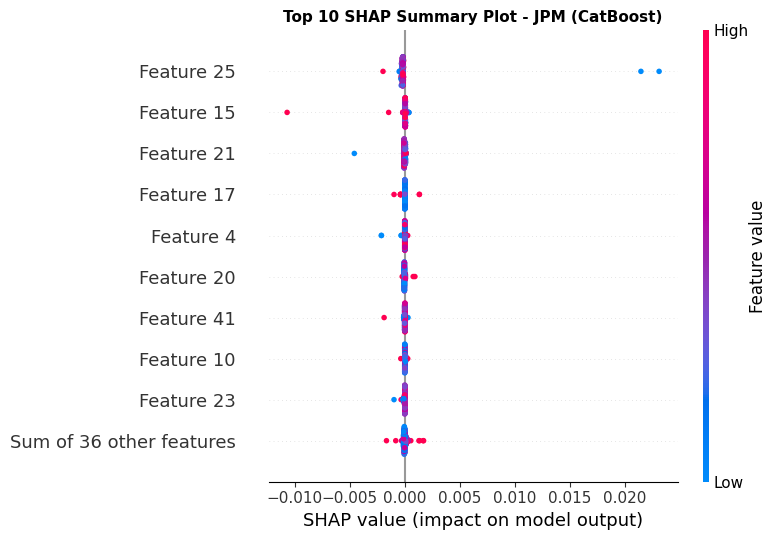


===== TOP 10 SHAP FEATURES - WFC (CatBoost) =====
          Feature  SHAP Importance
   VIX_momentum_5         0.000363
    volatility_20         0.000216
     Yield_Spread         0.000175
             MACD         0.000163
       VIX_return         0.000124
     lag_return_2         0.000119
SPX_volatility_20         0.000110
    overnight_gap         0.000106
 XLF_volatility_5         0.000098
  price_ma5_ratio         0.000097


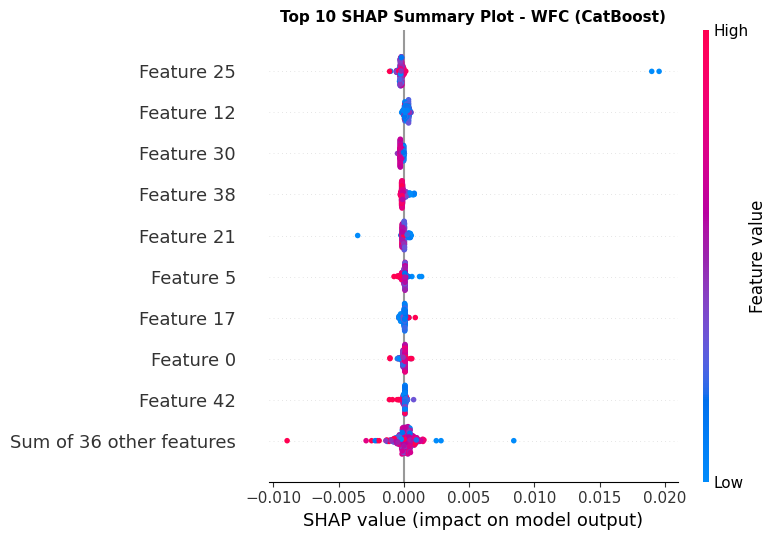


===== TOP 10 SHAP FEATURES - BAC (CatBoost) =====
        Feature  SHAP Importance
 VIX_momentum_5         0.000258
     VIX_return         0.000105
     SPX_return         0.000055
      return_3d         0.000051
price_ma5_ratio         0.000050
     XLF_return         0.000047
      return_1d         0.000041
           DGS2         0.000038
   lag_return_3         0.000033
  volatility_20         0.000033


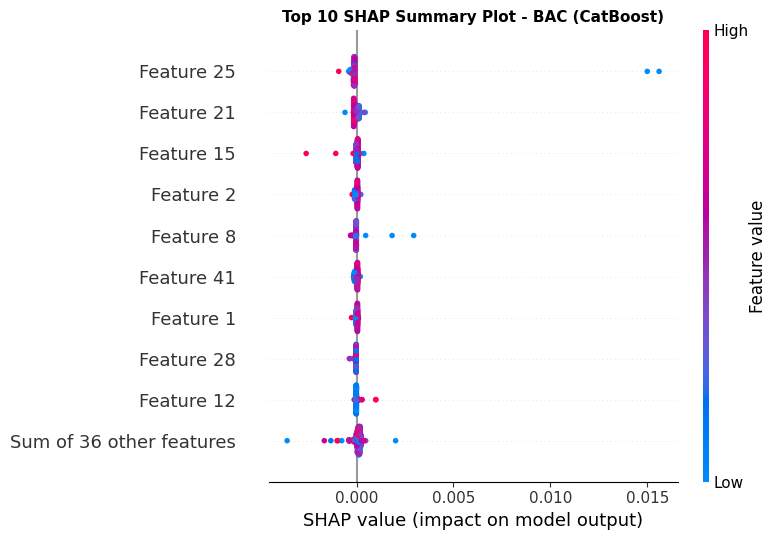

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "CatBoost"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]

    # Lọc snapshot năm 2025
    test_mask = df_single["Date"].dt.year == 2025
    df_oos = df_single.loc[test_mask].reset_index(drop=True)
    X_test_snapshot = df_oos[features_single].values

    current_model = fitted_models[TARGET_MODEL_NAME][ticker]

    # Tính SHAP
    explainer = shap.TreeExplainer(current_model)
    shap_vals = explainer(X_test_snapshot)
    shap_importance = np.abs(shap_vals.values).mean(axis=0)

    print(f"\n===== TOP 10 SHAP FEATURES - {ticker} ({TARGET_MODEL_NAME}) =====")
    importance_df = pd.DataFrame({
        "Feature": features_single,
        "SHAP Importance": np.round(shap_importance, 6)
    }).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

    print(importance_df.head(10).to_string(index=False))

    # Vẽ Summary Plot
    plt.figure(figsize=(9, 4.5))
    shap.plots.beeswarm(shap_vals, max_display=10, show=False)
    plt.title(f"Top 10 SHAP Summary Plot - {ticker} ({TARGET_MODEL_NAME})", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


===== TOP 10 SHAP FEATURES - JPM (XGBoost) =====
         Feature  SHAP Importance
   overnight_gap              0.0
       return_1d              0.0
       return_3d              0.0
       return_5d              0.0
    lag_return_1              0.0
    lag_return_2              0.0
    lag_return_3              0.0
    lag_return_5              0.0
 price_ma5_ratio              0.0
price_ma20_ratio              0.0


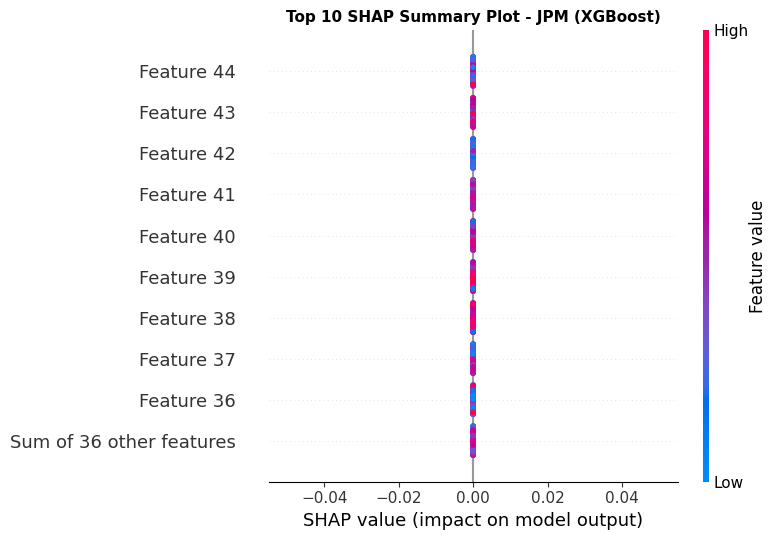


===== TOP 10 SHAP FEATURES - WFC (XGBoost) =====
         Feature  SHAP Importance
   overnight_gap              0.0
       return_1d              0.0
       return_3d              0.0
       return_5d              0.0
    lag_return_1              0.0
    lag_return_2              0.0
    lag_return_3              0.0
    lag_return_5              0.0
 price_ma5_ratio              0.0
price_ma20_ratio              0.0


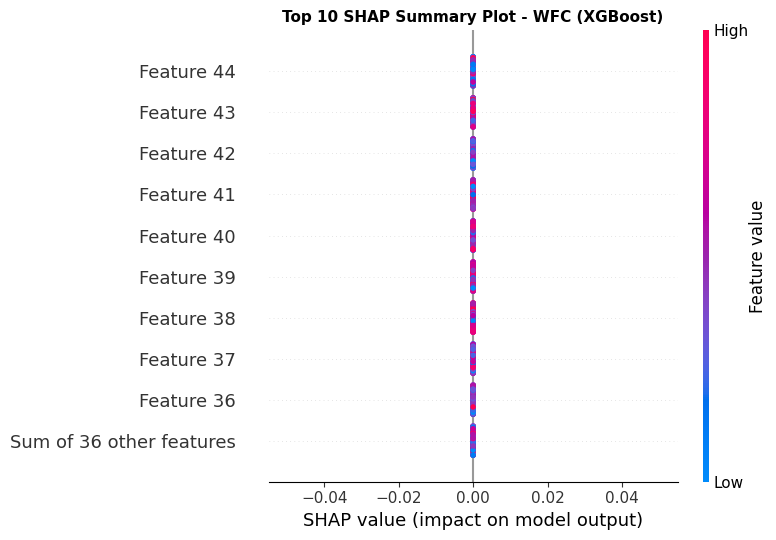


===== TOP 10 SHAP FEATURES - BAC (XGBoost) =====
         Feature  SHAP Importance
   overnight_gap              0.0
       return_1d              0.0
       return_3d              0.0
       return_5d              0.0
    lag_return_1              0.0
    lag_return_2              0.0
    lag_return_3              0.0
    lag_return_5              0.0
 price_ma5_ratio              0.0
price_ma20_ratio              0.0


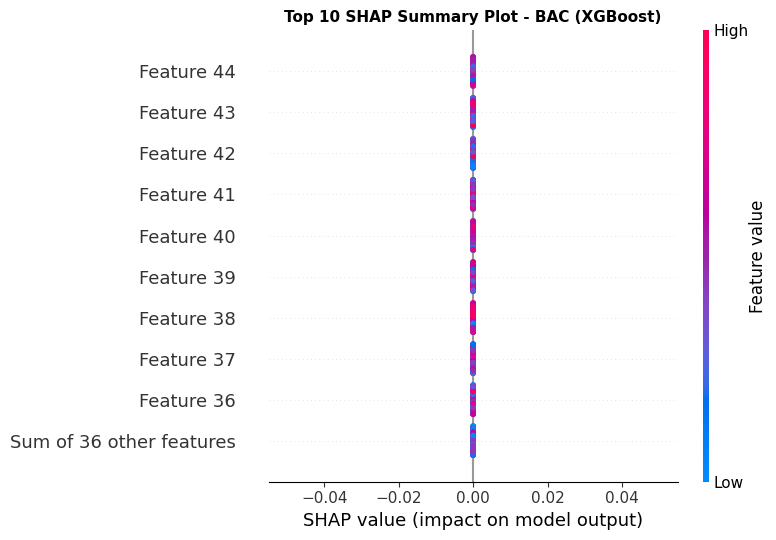

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

TARGET_MODEL_NAME = "XGBoost"
tickers = ["JPM", "WFC", "BAC"]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_features_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]

    # Lọc snapshot năm 2025
    test_mask = df_single["Date"].dt.year == 2025
    df_oos = df_single.loc[test_mask].reset_index(drop=True)
    X_test_snapshot = df_oos[features_single].values

    current_model = fitted_models[TARGET_MODEL_NAME][ticker]

    # Tính SHAP
    explainer = shap.TreeExplainer(current_model)
    shap_vals = explainer(X_test_snapshot)
    shap_importance = np.abs(shap_vals.values).mean(axis=0)

    print(f"\n===== TOP 10 SHAP FEATURES - {ticker} ({TARGET_MODEL_NAME}) =====")
    importance_df = pd.DataFrame({
        "Feature": features_single,
        "SHAP Importance": np.round(shap_importance, 6)
    }).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

    print(importance_df.head(10).to_string(index=False))

    # Vẽ Summary Plot
    plt.figure(figsize=(9, 4.5))
    shap.plots.beeswarm(shap_vals, max_display=10, show=False)
    plt.title(f"Top 10 SHAP Summary Plot - {ticker} ({TARGET_MODEL_NAME})", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [9]:
# MARKET REGIME ANALYSIS

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

tickers = ["JPM", "WFC", "BAC"]
test_years = [2023, 2024, 2025]

for ticker in tickers:
    if ticker not in all_dfs_master or ticker not in all_results_master:
        continue

    df_single = all_dfs_master[ticker]
    features_single = all_features_master[ticker]
    results_single = all_results_master[ticker]

    # Lọc toàn bộ giai đoạn Out-of-Sample (2023-2025)
    test_full_mask = df_single["Date"].dt.year.isin(test_years)
    df_oos_full = df_single.loc[test_full_mask].reset_index(drop=True)

    # Phân tách trạng thái qua VIX_Close (hoặc cột VIX đầu tiên tìm thấy)
    vix_cols = [c for c in features_single if "VIX" in c.upper()]
    if not vix_cols:
        continue

    vix_values = df_oos_full[vix_cols[0]].values
    median_vix = np.median(vix_values)

    regimes = {
        "Low VIX": vix_values < median_vix,
        "High VIX": vix_values >= median_vix
    }

    print(f"\n==================== MARKET REGIME ANALYSIS: {ticker} ====================")

    for model_name in ["XGBoost", "LightGBM", "CatBoost"]:
        actuals = np.array(results_single[model_name]["actuals"])
        preds = np.array(results_single[model_name]["preds"])

        regime_report = []
        for r_name, mask in regimes.items():
            r_actuals = actuals[mask]
            r_preds = preds[mask]

            if len(r_actuals) == 0:
                continue

            r_rmse = np.sqrt(mean_squared_error(r_actuals, r_preds))
            r_mae = mean_absolute_error(r_actuals, r_preds)

            # Tính Directional Accuracy theo ngưỡng Mean động
            r_threshold = np.mean(r_preds)
            dir_act = np.where(r_actuals > 0, 1, 0)
            dir_pred = np.where(r_preds > r_threshold, 1, 0)
            r_acc = np.mean(dir_act == dir_pred) * 100

            regime_report.append({
                "Model": model_name,
                "Regime": r_name,
                "Samples": len(r_actuals),
                "RMSE": round(r_rmse, 5),
                "MAE": round(r_mae, 5),
                "Dir Acc (%)": round(r_acc, 2)
            })

        print(pd.DataFrame(regime_report).to_string(index=False))
    print("=" * 74)


==================== MARKET REGIME ANALYSIS: JPM ====================
  Model   Regime  Samples    RMSE     MAE  Dir Acc (%)
XGBoost  Low VIX      375 0.01099 0.00790        46.13
XGBoost High VIX      376 0.01735 0.01189        48.67
   Model   Regime  Samples    RMSE     MAE  Dir Acc (%)
LightGBM  Low VIX      375 0.01107 0.00807         52.0
LightGBM High VIX      376 0.01746 0.01214         50.0
   Model   Regime  Samples    RMSE     MAE  Dir Acc (%)
CatBoost  Low VIX      375 0.01107 0.00797        45.33
CatBoost High VIX      376 0.01750 0.01200        48.40

==================== MARKET REGIME ANALYSIS: WFC ====================
  Model   Regime  Samples    RMSE     MAE  Dir Acc (%)
XGBoost  Low VIX      375 0.01442 0.01077        50.13
XGBoost High VIX      376 0.02082 0.01439        49.20
   Model   Regime  Samples    RMSE     MAE  Dir Acc (%)
LightGBM  Low VIX      375 0.01463 0.01086        51.73
LightGBM High VIX      376 0.02084 0.01458        49.47
   Model   Regime  Sampl

 KHỞI CHẠY BƯỚC 3: ECONOMIC EVALUATION & BACKTEST CHIẾN LƯỢC TOÀN HỆ THỐNG

==================== ECONOMIC EVALUATION: JPM ====================
   Model  Cum Ret (%)  Ann Ret (%)  Sharpe  Max DD (%)  Win Rate (%)  Turnover (%)
 XGBoost        32.89        10.01  0.7350      -25.29         56.63          0.13
LightGBM       109.78        28.22  1.6199      -23.89         57.49         41.94
CatBoost        41.22        12.28  0.8727      -17.33         56.22         29.03


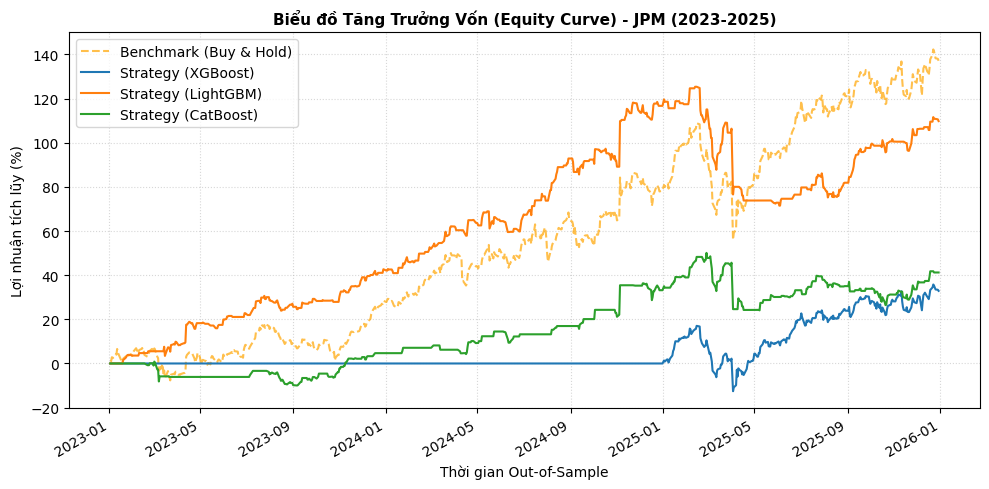


==================== ECONOMIC EVALUATION: WFC ====================
   Model  Cum Ret (%)  Ann Ret (%)  Sharpe  Max DD (%)  Win Rate (%)  Turnover (%)
 XGBoost        29.99         9.20  0.6072      -25.86         54.22          0.13
LightGBM        69.41        19.35  1.0699      -17.13         54.36         40.21
CatBoost       115.74        29.43  1.4752      -19.82         55.74         35.95


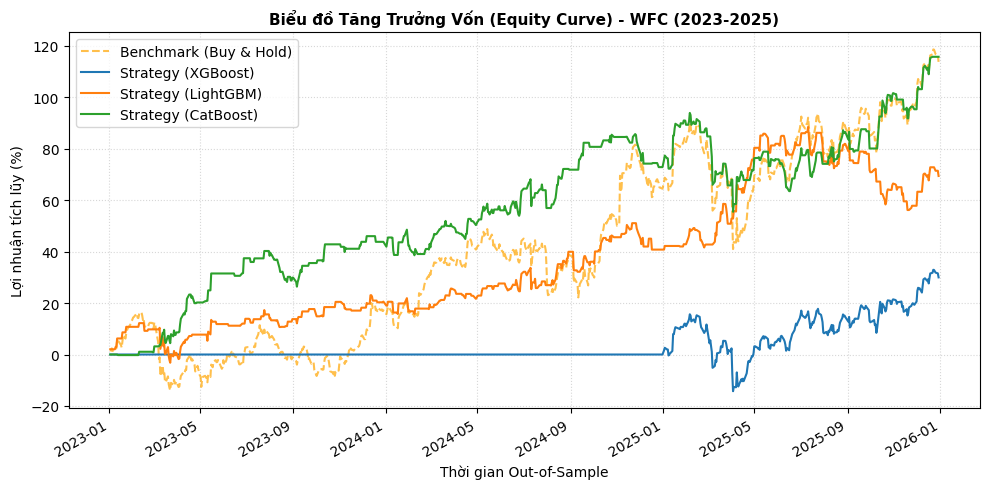


==================== ECONOMIC EVALUATION: BAC ====================
   Model  Cum Ret (%)  Ann Ret (%)  Sharpe  Max DD (%)  Win Rate (%)  Turnover (%)
 XGBoost        23.26         7.27  0.4307      -31.80         51.90          0.27
LightGBM       116.65        29.62  1.6078      -11.97         55.23         41.94
CatBoost        57.60        16.49  1.0671      -27.38         56.60         30.23


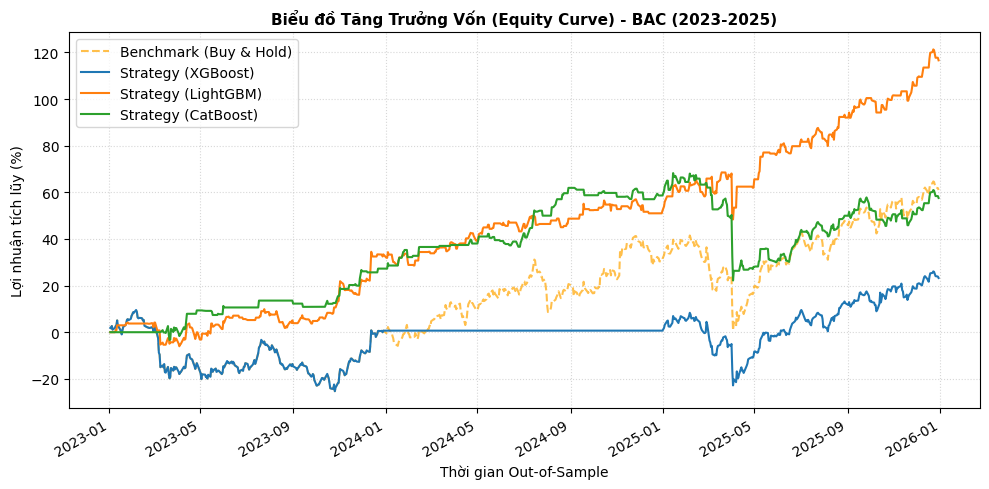

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("==========================================================================================")
print(" KHỞI CHẠY BƯỚC 3: ECONOMIC EVALUATION & BACKTEST CHIẾN LƯỢC TOÀN HỆ THỐNG")
print("==========================================================================================")

tickers = ["JPM", "WFC", "BAC"]
models = ["XGBoost", "LightGBM", "CatBoost"]

for ticker in tickers:
    if ticker not in all_results_master or ticker not in all_dfs_master:
        continue

    df_single = all_dfs_master[ticker]

    # Lấy chuỗi ngày tương ứng với giai đoạn Out-of-Sample (2023-2025) để vẽ đồ thị có trục thời gian
    test_years = [2023, 2024, 2025]
    dates_oos = df_single.loc[df_single["Date"].dt.year.isin(test_years), "Date"].reset_index(drop=True)

    print(f"\n==================== ECONOMIC EVALUATION: {ticker} ====================")

    plt.figure(figsize=(10, 5))

    # Tính toán đường Benchmark Buy & Hold (Lấy từ actuals của mô hình bất kỳ vì actuals là như nhau)
    sample_actuals = np.array(all_results_master[ticker]["LightGBM"]["actuals"])
    cum_actual = (1 + sample_actuals).cumprod() - 1
    plt.plot(dates_oos, cum_actual * 100, label="Benchmark (Buy & Hold)", color="orange", linestyle="--", alpha=0.7)

    econ_report = []

    for model_name in models:
        actuals = np.array(all_results_master[ticker][model_name]["actuals"])
        preds = np.array(all_results_master[ticker][model_name]["preds"])

        # Thiết lập tín hiệu dựa trên ngưỡng Mean động để đảm bảo tính phân tách hai chiều
        mean_threshold = np.mean(preds)
        signals = np.where(preds > mean_threshold, 1, 0)

        # Lợi nhuận chiến lược: 1 -> Long (Hưởng thực tế), 0 -> Cash (Lợi nhuận = 0)
        strat_returns = signals * actuals
        cum_strat = (1 + strat_returns).cumprod() - 1

        # 1. Lợi nhuận tích lũy (Cumulative Return)
        final_cum_ret = cum_strat[-1]

        # 2. Lợi nhuận chuẩn hóa năm (Annualized Return - Giả định 252 ngày giao dịch)
        n_days = len(actuals)
        ann_ret = (1 + final_cum_ret) ** (252 / n_days) - 1

        # 3. Hệ số Sharpe (Giả định Risk-Free Rate = 0)
        daily_std = strat_returns.std()
        sharpe = (strat_returns.mean() / daily_std) * np.sqrt(252) if daily_std != 0 else 0

        # 4. Sụt giảm tài sản tối đa (Max Drawdown) - SỬA LỖI TẠI ĐÂY
        # Chuyển đổi mảng trị giá tài sản lũy kế sang Pandas Series để sử dụng .cummax() an toàn
        equity_curve = pd.Series((1 + strat_returns).cumprod())
        running_max = equity_curve.cummax()
        drawdown = (equity_curve - running_max) / running_max
        max_dd = drawdown.min()

        # 5. Tỷ lệ chiến thắng (Win Rate của các phiên kích hoạt vị thế Long)
        active_trades = actuals[signals == 1]
        win_rate = np.mean(active_trades > 0) * 100 if len(active_trades) > 0 else 0

        # 6. Tần suất giao dịch (Turnover Rate dựa trên số lần thay đổi vị thế)
        pos_changes = np.sum(np.abs(np.diff(signals)))
        turnover = pos_changes / n_days

        econ_report.append({
            "Model": model_name,
            "Cum Ret (%)": round(final_cum_ret * 100, 2),
            "Ann Ret (%)": round(ann_ret * 100, 2),
            "Sharpe": round(sharpe, 4),
            "Max DD (%)": round(max_dd * 100, 2),
            "Win Rate (%)": round(win_rate, 2),
            "Turnover (%)": round(turnover * 100, 2)
        })

        # Vẽ Equity Curve cho từng mô hình
        plt.plot(dates_oos, cum_strat * 100, label=f"Strategy ({model_name})", linewidth=1.5)

    # In bảng báo cáo định lượng
    print(pd.DataFrame(econ_report).to_string(index=False))

    # Định dạng đồ thị Equity Curve chuẩn Quant Report
    plt.title(f"Biểu đồ Tăng Trưởng Vốn (Equity Curve) - {ticker} (2023-2025)", fontsize=11, fontweight="bold")
    plt.xlabel("Thời gian Out-of-Sample")
    plt.ylabel("Lợi nhuận tích lũy (%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

    print("=" * 74)